# Сравнение `model_advanced.pkl` и `hw6_gradient_boosting`

В этом ноутбуке сравнивается базовая модель `model_advanced.pkl` с моделью `gradient_boosting` из `hw6` на одном и том же временном разбиении: `train / validation / test`.

Основные цели:
- сохранить разбиение из исходного `model-validation.ipynb`
- переобучить `hw6 gradient_boosting` на точно таком же тренировочном окне
- сравнить качество ранжирования на валидации
- измерить, как изменяется риск по решающим сегментам  после обновления модели
- проверить стабильность децилей на тестовой выборке во времени

## План анализа

1. Загрузить все необходимые CSV-файлы
2. Воссоздать временное разбиение, использованное в исходном блокноте
3. Подготовить данные и добавить 5 сконструированных признаков из `hw2`
4. Загрузить `model_advanced.pkl` и переобучить `hw6 gradient_boosting`
5. Сравнить модели по `ROC-AUC`, кривым сортировки и решающим сегментам
6. Проверить стабильность децилей на тестовом потоке во времени
7. Сохранить все полученные графики в папку `metrics`

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from IPython.display import Markdown, display
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

from config import (
    NUMERICAL_FEATURES,
    CAT_FEATURES,
    TARGET,
    EXT_SOURCE_FEATURES,
)

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)

metrics_dir = Path("./metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

MODEL_NAME_BASE = "model_advanced.pkl"
MODEL_NAME_CANDIDATE = "hw6 gradient_boosting"

## 1. Обнаружение и загрузка данных

Блокнот автоматически определяет папку с исходными CSV-файлами. Это обеспечивает устойчивость выполнения в разных рабочих директориях.

In [ ]:
# Поиск данных
candidate_dirs = [
    Path("./src/metrics"),
    Path("../metrics"),
    Path("./home-credit-default-risk"),
    Path("."),
]

data_dir = None
for candidate in candidate_dirs:
    if (candidate / "application_train.csv").exists() and (candidate / "application_test.csv").exists():
        data_dir = candidate
        break

if data_dir is None:
    raise FileNotFoundError(
        "Не удалось найти папку с файлами application_train.csv и application_test.csv. "
        "Перепроверьте cписочек выше"
    )

print("Using data_dir:", data_dir.resolve())

if "data" not in globals():
    data = {}

required_files = [
    "application_train",
    "application_test",
    "bureau",
    "previous_application",
]

for file_name in required_files:
    file_path = data_dir / f"{file_name}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path.resolve()}")
    if file_name not in data:
        print(f"Loading {file_name}.csv ...")
        data[file_name] = pd.read_csv(file_path)

print("Loaded tables:", ", ".join(sorted(data.keys())))

Using data_dir: C:\Users\denis\credit_scoring\src\metrics
Loading application_train.csv ...
Loading application_test.csv ...
Loading bureau.csv ...
Loading previous_application.csv ...
Loaded tables: application_test, application_train, bureau, previous_application


## 2. Воссоздание временного разбиения

В этом разделе воспроизводится логика разбиения из исходного блокнота:
- объединить `application_train` и `application_test`;
- получить прокси-дату заявки из `SK_ID_CURR`;
- использовать пороговую дату `2023-09-01` для разделения `training` и `validation`;
- считать отсутствие `TARGET` как `test`.

In [9]:
application = pd.concat(
    [
        data["application_train"],
        data["application_test"],
    ],
    axis=0,
).sort_values("SK_ID_CURR").reset_index(drop=True)

ids = application["SK_ID_CURR"]
application["DAY_OF_YEAR"] = ((ids - ids.min()) / (ids.max() - ids.min()) * 365 + 1).astype(int)
application["DATE_OF_APPLICATION"] = pd.to_datetime(
    2023 * 1000 + application["DAY_OF_YEAR"],
    format="%Y%j",
)

application["IS_TRAINING"] = False
application.loc[
    application["DATE_OF_APPLICATION"].le("2023-09-01")
    & application["TARGET"].notna(),
    "IS_TRAINING",
] = True

application["group"] = "training"
application.loc[application["TARGET"].isna(), "group"] = "test"
application.loc[
    application["TARGET"].notna() & application["IS_TRAINING"].eq(False),
    "group",
] = "validation"

split_summary = application.groupby("group", observed=True).agg(
    loans=pd.NamedAgg(column="SK_ID_CURR", aggfunc="count"),
    target_rate=pd.NamedAgg(column="TARGET", aggfunc="mean"),
    min_date=pd.NamedAgg(column="DATE_OF_APPLICATION", aggfunc="min"),
    max_date=pd.NamedAgg(column="DATE_OF_APPLICATION", aggfunc="max"),
)

cash_loan_summary = application[
    application["NAME_CONTRACT_TYPE"].eq("Cash loans")
].groupby("group", observed=True).agg(
    loans=pd.NamedAgg(column="SK_ID_CURR", aggfunc="count"),
    target_rate=pd.NamedAgg(column="TARGET", aggfunc="mean"),
)

display(split_summary)
display(cash_loan_summary)

,loans,target_rate,min_date,max_date
group,,,,
test,48744,NaN,2023-01-01,2023-12-31
training,205458,0.081204,2023-01-01,2023-09-01
validation,102053,0.079772,2023-09-02,2024-01-01


,loans,target_rate
group,,
test,48305,NaN
training,186008,0.083873
validation,92224,0.082625


## 3. Подготовка данных и feature engineering

На этом этапе мы:
- сохраняем ту же обработку пропущенных значений, что и в исходном блокноте
- создаём 5 дополнительных признаков из `hw6`
- формируем итоговый набор данных для сравнения

In [10]:
# Сохраняем ту же обрабокту пропущенных значений, что и в исходном блокноте
application[NUMERICAL_FEATURES] = application[NUMERICAL_FEATURES].fillna(-1)
application[EXT_SOURCE_FEATURES] = application[EXT_SOURCE_FEATURES].fillna(-1)
application[CAT_FEATURES] = application[CAT_FEATURES].fillna("XNA")

bureau = data["bureau"].copy()
previous_application = data["previous_application"].copy()


def build_hw6_features(application_df, bureau_df, previous_application_df):

    """Билдим фичи из  hw6 (hw2)"""

    features_app = application_df[
        ["SK_ID_CURR", "AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY"]
    ].copy()

    income_nonzero = features_app["AMT_INCOME_TOTAL"].replace(0, np.nan)
    features_app["credit_to_income_ratio"] = (
        features_app["AMT_CREDIT"] / income_nonzero
    ).round(4)
    features_app["annuity_to_income_ratio"] = (
        features_app["AMT_ANNUITY"] / income_nonzero
    ).round(4)
    features_app = features_app[
        ["SK_ID_CURR", "credit_to_income_ratio", "annuity_to_income_ratio"]
    ]

    active_credit_count = (
        bureau_df.loc[bureau_df["CREDIT_ACTIVE"].eq("Active"), ["SK_ID_CURR"]]
        .groupby("SK_ID_CURR", as_index=False)
        .size()
        .rename(columns={"size": "active_credit_count"})
    )

    credit_history_days = (
        bureau_df.groupby("SK_ID_CURR", as_index=False)["DAYS_CREDIT"]
        .min()
        .rename(columns={"DAYS_CREDIT": "credit_history_days"})
    )
    credit_history_days["credit_history_days"] = credit_history_days["credit_history_days"].abs()

    prev_application_count = (
        previous_application_df.groupby("SK_ID_CURR", as_index=False)
        .size()
        .rename(columns={"size": "prev_application_count"})
    )

    features = features_app.merge(active_credit_count, on="SK_ID_CURR", how="left")
    features = features.merge(credit_history_days, on="SK_ID_CURR", how="left")
    features = features.merge(prev_application_count, on="SK_ID_CURR", how="left")

    fill_zero_cols = [
        "active_credit_count",
        "credit_history_days",
        "prev_application_count",
    ]
    features[fill_zero_cols] = features[fill_zero_cols].fillna(0)

    return features

In [11]:
hw6_extra_features = build_hw6_features(
    application_df=application,
    bureau_df=bureau,
    previous_application_df=previous_application,
)

application_cmp = application.drop(
    columns=[
        "credit_to_income_ratio",
        "annuity_to_income_ratio",
        "active_credit_count",
        "credit_history_days",
        "prev_application_count",
    ],
    errors="ignore",
).merge(
    hw6_extra_features,
    on="SK_ID_CURR",
    how="left",
)

training_cmp = application_cmp[
    application_cmp["NAME_CONTRACT_TYPE"].eq("Cash loans")
    & application_cmp["group"].eq("training")
].reset_index(drop=True)

validation_cmp = application_cmp[
    application_cmp["NAME_CONTRACT_TYPE"].eq("Cash loans")
    & application_cmp["group"].eq("validation")
].reset_index(drop=True)

test_cmp = application_cmp[
    application_cmp["NAME_CONTRACT_TYPE"].eq("Cash loans")
    & application_cmp["group"].eq("test")
].reset_index(drop=True)

split_check = pd.DataFrame(
    {
        "dataset": ["training", "validation", "test"],
        "rows": [len(training_cmp), len(validation_cmp), len(test_cmp)],
        "target_rate": [
            training_cmp[TARGET].mean(),
            validation_cmp[TARGET].mean(),
            np.nan,
        ],
    }
)

display(split_check)

,dataset,rows,target_rate
0,training,186008,0.083873
1,validation,92224,0.082625
2,test,48305,NaN


## 4. Загрузка baseline-модели и обучение кандидата

`model_advanced.pkl` используется в качестве baseline-модели.

`hw6 gradient_boosting` переобучается на точно таком же обучающем срезе, чтобы обеспечить честное сравнение.

In [12]:
model_advanced_cmp = CatBoostClassifier().load_model("./model_advanced.pkl")

HW6_NUM_FEATURES = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
    "credit_to_income_ratio",
    "annuity_to_income_ratio",
    "active_credit_count",
    "credit_history_days",
    "prev_application_count",
]

HW6_CAT_FEATURES = [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

HW6_ALL_FEATURES = HW6_NUM_FEATURES + HW6_CAT_FEATURES

hw6_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            HW6_NUM_FEATURES,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]
            ),
            HW6_CAT_FEATURES,
        ),
    ]
)

model_hw6_cmp = Pipeline(
    steps=[
        ("preprocessor", hw6_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.07939369587501735,
                max_depth=5,
                max_leaf_nodes=63,
                min_samples_leaf=88,
                l2_regularization=0.7018341774283952,
                max_iter=250,
                random_state=42,
            ),
        ),
    ]
)

model_hw6_cmp.fit(
    training_cmp[HW6_ALL_FEATURES],
    training_cmp[TARGET].astype(int),
)

print(f"{MODEL_NAME_CANDIDATE} переобучена на тренировочном разбиении из блокнота")

hw6 gradient_boosting переобучена на тренировочном разбиении из блокнота


## 5. Вспомогательные функции для аналитики моделей

Эти утилиты обеспечивают согласованность генерации децилей, сопоставления решающих сегментов (decision bucket mapping) и отслеживания децилей во времени для обеих моделей.

In [13]:
def add_deciles(df, proba_col, prefix):

    """Добавить интервальные и числовые децильные сегменты (buckets) на основе вероятности дефолта"""
    
    df = df.copy()
    df[f"QUANTILE_{prefix}"] = pd.qcut(
        df[proba_col],
        q=10,
        duplicates="drop",
    )
    n_bins = df[f"QUANTILE_{prefix}"].cat.categories.size
    df[f"DECILE_{prefix}"] = pd.qcut(
        df[proba_col],
        q=n_bins,
        labels=np.arange(n_bins),
        duplicates="drop",
    ).astype(int)
    return df


def build_sort_table(df, decile_col):

    """Построить таблицу сортировки: размер сегмента и среднее значение целевой переменной"""

    return df.groupby(decile_col, observed=True).agg(
        count=pd.NamedAgg(column="SK_ID_CURR", aggfunc="count"),
        target=pd.NamedAgg(column=TARGET, aggfunc="mean"),
    )


def add_policy_background(ax):

    """Выделить сегменты решающей политики на кривой сортировки"""
    
    ax.add_patch(
        patches.Rectangle((-0.5, 0), 4, 0.275, linewidth=0, facecolor="green", alpha=0.3)
    )
    ax.add_patch(
        patches.Rectangle((3.5, 0), 4, 0.275, linewidth=0, facecolor="lightgreen", alpha=0.3)
    )
    ax.add_patch(
        patches.Rectangle((7.5, 0), 1, 0.275, linewidth=0, facecolor="yellow", alpha=0.3)
    )
    ax.add_patch(
        patches.Rectangle((8.5, 0), 1, 0.275, linewidth=0, facecolor="red", alpha=0.3)
    )

    ax.text(
        0.5,
        0.2,
        "No amount\nlimits",
        color="k",
        bbox=dict(facecolor="green", lw=0, alpha=0.3, boxstyle="round, pad=0.3"),
    )
    ax.text(
        4,
        0.2,
        "Light amount\nlimits",
        color="k",
        bbox=dict(facecolor="lightgreen", lw=0, alpha=0.3, boxstyle="round, pad=0.3"),
    )
    ax.text(
        7.5,
        0.05,
        "Strict\nlimits",
        color="k",
        bbox=dict(facecolor="yellow", lw=0, alpha=0.4, boxstyle="round, pad=0.3"),
    )
    ax.text(
        8.5,
        0.125,
        "Reject",
        color="k",
        bbox=dict(facecolor="red", lw=0, alpha=0.4, boxstyle="round, pad=0.3"),
    )


def assign_categories(df, decile_col, new_col):

    """Сопоставить децили с сегментами принятия решений"""

    labels = [
        "No amount limits",
        "Light amount limits",
        "Strict limits",
        "Reject",
    ]
    df = df.copy()
    df[new_col] = pd.cut(
        df[decile_col],
        bins=[-np.inf, 3.5, 7.5, 8.5, np.inf],
        labels=labels,
        ordered=True,
    )
    return df


def assign_test_deciles_from_validation(test_df, validation_df, proba_col, quantile_col, new_col):

    """Применить границы квантилей, полученные на валидации, к тестовому потоку"""

    test_df = test_df.copy()
    test_df[new_col] = 0

    quantile_thresholds = validation_df[quantile_col].cat.categories
    for decile, interval in enumerate(quantile_thresholds):
        test_df.loc[test_df[proba_col].gt(interval.left), new_col] = decile

    test_df[new_col] = test_df[new_col].astype(int)
    return test_df


def build_time_distribution(df, decile_col, res="3d"):

    """Построить распределение долей децилей во времени"""
    
    info = (
        df.groupby(
            [pd.Grouper(key="DATE_OF_APPLICATION", freq=res), decile_col],
            observed=True,
        )["SK_ID_CURR"]
        .count()
        .unstack()
        .fillna(0)
    )
    info = info.reindex(sorted(info.columns, reverse=True), axis=1)
    info = info.div(info.sum(axis=1), axis=0).fillna(0)
    return info

## 6. Оценка на валидации

Сначала вычисляются вероятности дефолта и `ROC-AUC`. Затем строятся децили для обеих моделей и подготавливаются сводные таблицы для графиков.

In [14]:
validation_cmp = validation_cmp.copy()
validation_cmp["PROBA_advanced"] = model_advanced_cmp.predict_proba(
    validation_cmp[NUMERICAL_FEATURES + CAT_FEATURES + EXT_SOURCE_FEATURES]
)[:, 1]
validation_cmp["PROBA_hw6"] = model_hw6_cmp.predict_proba(
    validation_cmp[HW6_ALL_FEATURES]
)[:, 1]

roc_advanced = roc_auc_score(validation_cmp[TARGET], validation_cmp["PROBA_advanced"])
roc_hw6 = roc_auc_score(validation_cmp[TARGET], validation_cmp["PROBA_hw6"])

summary_metrics = pd.DataFrame(
    {
        "model": [MODEL_NAME_BASE, MODEL_NAME_CANDIDATE],
        "roc_auc_validation": [roc_advanced, roc_hw6],
    }
)

display(summary_metrics)

validation_cmp = add_deciles(validation_cmp, "PROBA_advanced", "advanced")
validation_cmp = add_deciles(validation_cmp, "PROBA_hw6", "hw6")

sort_table_advanced_cmp = build_sort_table(validation_cmp, "DECILE_advanced")
sort_table_hw6_cmp = build_sort_table(validation_cmp, "DECILE_hw6")

validation_decile_compare = pd.DataFrame(
    {
        "advanced_target": sort_table_advanced_cmp["target"],
        "hw6_target": sort_table_hw6_cmp["target"],
        "advanced_count": sort_table_advanced_cmp["count"],
        "hw6_count": sort_table_hw6_cmp["count"],
    }
)

display(validation_decile_compare)

,model,roc_auc_validation
0,model_advanced.pkl,0.673245
1,hw6 gradient_boosting,0.756822


,advanced_target,hw6_target,advanced_count,hw6_count
0,0.027431,0.012252,9223,9223
1,0.042073,0.021796,9222,9222
2,0.047712,0.029386,9222,9222
3,0.051502,0.036322,9223,9223
4,0.060616,0.049339,9222,9222
5,0.072761,0.062459,9222,9222
6,0.088366,0.077090,9223,9223
7,0.102039,0.106810,9222,9222
8,0.138799,0.152895,9222,9222
9,0.194947,0.277892,9223,9223


DECILE_hw6,0,1,2,3,4,5,6,7,8,9
DECILE_advanced,,,,,,,,,,
0,3550,1841,1217,825,638,447,330,207,121,47
1,1956,1709,1444,1098,906,753,578,400,275,103
2,1304,1539,1353,1215,1070,969,711,502,388,171
3,946,1287,1269,1234,1134,973,904,682,514,280
4,610,970,1184,1259,1135,1140,993,915,627,389
5,358,727,988,1086,1103,1219,1173,1080,878,610
6,227,525,779,936,1109,1120,1188,1279,1178,882
7,156,362,550,770,964,1103,1286,1374,1424,1233
8,84,198,288,548,731,933,1160,1485,1768,2027


DECILE_hw6,0,1,2,3,4,5,6,7,8,9
DECILE_advanced,,,,,,,,,,
0,38.5,20.0,13.2,8.9,6.9,4.8,3.6,2.2,1.3,0.5
1,21.2,18.5,15.7,11.9,9.8,8.2,6.3,4.3,3.0,1.1
2,14.1,16.7,14.7,13.2,11.6,10.5,7.7,5.4,4.2,1.9
3,10.3,14.0,13.8,13.4,12.3,10.5,9.8,7.4,5.6,3.0
4,6.6,10.5,12.8,13.7,12.3,12.4,10.8,9.9,6.8,4.2
5,3.9,7.9,10.7,11.8,12.0,13.2,12.7,11.7,9.5,6.6
6,2.5,5.7,8.4,10.1,12.0,12.1,12.9,13.9,12.8,9.6
7,1.7,3.9,6.0,8.3,10.5,12.0,13.9,14.9,15.4,13.4
8,0.9,2.1,3.1,5.9,7.9,10.1,12.6,16.1,19.2,22.0


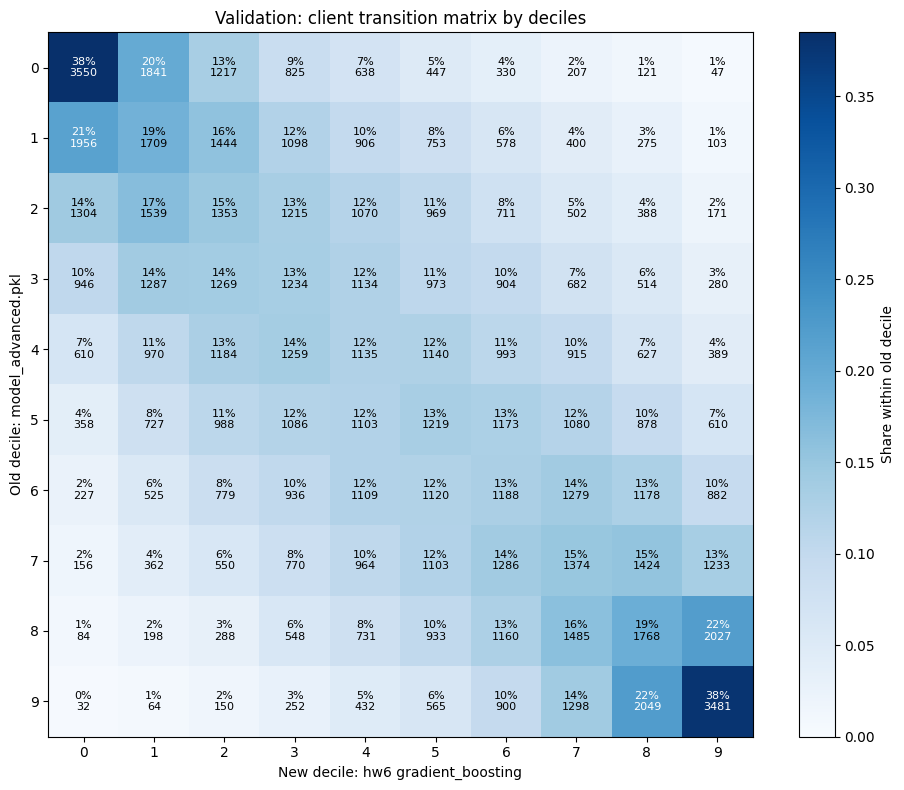

Saved: C:\Users\denis\credit_scoring\notebooks\hw7\metrics\04_validation_decile_transition_matrix_hw6_vs_advanced.png


In [ ]:
# Матрица переходов клиентов между децилями:
# строки - дециль старой модели model_advanced.pkl
# столбцы - дециль новой модели hw6 gradient_boosting

decile_order = list(range(10))

transition_counts = pd.crosstab(
    validation_cmp["DECILE_advanced"],
    validation_cmp["DECILE_hw6"],
).reindex(index=decile_order, columns=decile_order, fill_value=0)

transition_share = transition_counts.div(
    transition_counts.sum(axis=1).replace(0, np.nan),
    axis=0,
).fillna(0)

transition_share_pct = (transition_share * 100).round(1)

display(transition_counts)
display(transition_share_pct)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    transition_share.values,
    cmap="Blues",
    vmin=0,
    vmax=transition_share.values.max(),
)

ax.set_title("Validation: client transition matrix by deciles")
ax.set_xlabel(f"New decile: {MODEL_NAME_CANDIDATE}")
ax.set_ylabel(f"Old decile: {MODEL_NAME_BASE}")

ax.set_xticks(np.arange(len(decile_order)))
ax.set_yticks(np.arange(len(decile_order)))
ax.set_xticklabels(decile_order)
ax.set_yticklabels(decile_order)

for i in range(len(decile_order)):
    for j in range(len(decile_order)):
        count = transition_counts.iloc[i, j]
        share = transition_share.iloc[i, j]

        if count > 0:
            color = "white" if share > transition_share.values.max() / 2 else "black"
            ax.text(
                j,
                i,
                f"{share:.0%}\n{count}",
                ha="center",
                va="center",
                fontsize=8,
                color=color,
            )

fig.colorbar(im, ax=ax, label="Share within old decile")
fig.tight_layout()

transition_path = metrics_dir / "04_validation_decile_transition_matrix_hw6_vs_advanced.png"
fig.savefig(transition_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", transition_path.resolve())


### Вывод по матрице переходов клиентов между децилями


Основная масса клиентов остается около диагонали матрицы: чем ниже дециль в старой модели, тем чаще клиент попадает в низкие децили новой модели, и наоборот. Это значит, что новая модель в целом сохраняет порядок рискованности клиентов, а не переставляет их случайным образом.

При этом совпадение децилей не идеальное. к примеру, из 0-го дециля старой модели только 38.5% клиентов остаются в 0-м дециле новой модели, а остальные распределяются по соседним и более высоким децилям. Аналогично, из 9-го дециля старой модели 37.7% клиентов остаются в 9-м дециле новой модели, но заметная часть переходит в 7-й и 8-й децили.

Наиболее стабильны крайние группы: клиенты из самых безопасных и самых рискованных децилей чаще остаются в близких по смыслу сегментах. В средних децилях переходы более размазаны, что ожидаемо, потому что границы между клиентами среднего риска менее устойчивы.



## 7. Визуализация 1. Кривые сортировки 

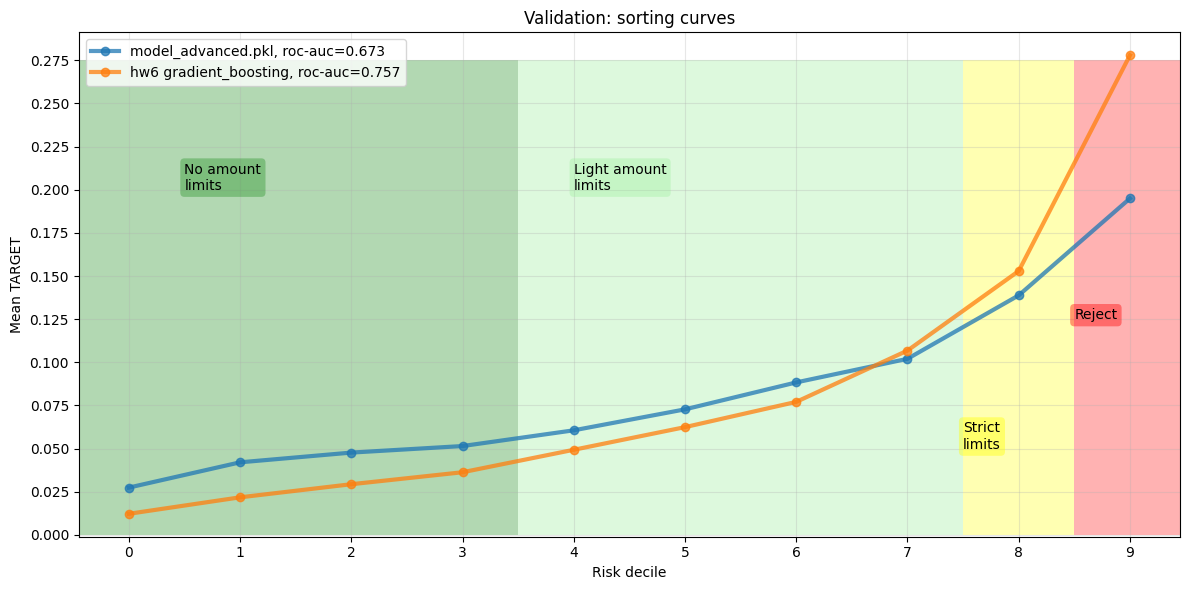

Saved: C:\Users\denis\credit_scoring\notebooks\hw7\metrics\01_validation_sort_curve_hw6_vs_advanced.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

sort_table_advanced_cmp["target"].plot(
    ax=ax,
    marker="o",
    lw=3,
    alpha=0.75,
    xticks=np.arange(10),
    label=f"{MODEL_NAME_BASE}, roc-auc={roc_advanced:.3f}",
)

sort_table_hw6_cmp["target"].plot(
    ax=ax,
    marker="o",
    lw=3,
    alpha=0.75,
    xticks=np.arange(10),
    label=f"{MODEL_NAME_CANDIDATE}, roc-auc={roc_hw6:.3f}",
)

ax.set_title("Validation: sorting curves")
ax.set_xlabel("Risk decile")
ax.set_ylabel("Mean TARGET")
ax.set_yticks(np.arange(0, 0.30, 0.025))
ax.set_xticklabels(np.arange(10))
ax.grid(True, alpha=0.3)
ax.legend()

add_policy_background(ax)

sort_curve_path = metrics_dir / "01_validation_sort_curve_hw6_vs_advanced.png"
fig.tight_layout()
fig.savefig(sort_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", sort_curve_path.resolve())

На валидационной выборке hw6_gradient_boosting заметно лучше разделяет клиентов по уровню риска, чем model_advanced.pkl. Это видно и по интегральной метрике ROC-AUC (0.757 против 0.673), и по форме сортировочной кривой: в низкорисковых децилях 0-6 средний TARGET у новой модели ниже, а в высокорисковых децилях 8-9 выше. Обратим внимание на последний дециль: для hw6_gradient_boosting риск в нем существенно выше, чем у baseline, то есть модель лучше концентрирует самых проблемных клиентов в зоне отказа. С точки зрения скоринга это хороший результат: ранжирование стало более контрастным, а граница между хорошими и плохими клиентами стала четче. 

## 8. Визуализация 2. Среднее значение TARGET по решающим сегментам (decision bucket)


,advanced_target,hw6_target,advanced_count,hw6_count
No amount limits,0.042179,0.024939,36890,36890
Light amount limits,0.080946,0.073924,36889,36889
Strict limits,0.138799,0.152895,9222,9222
Reject,0.194947,0.277892,9223,9223


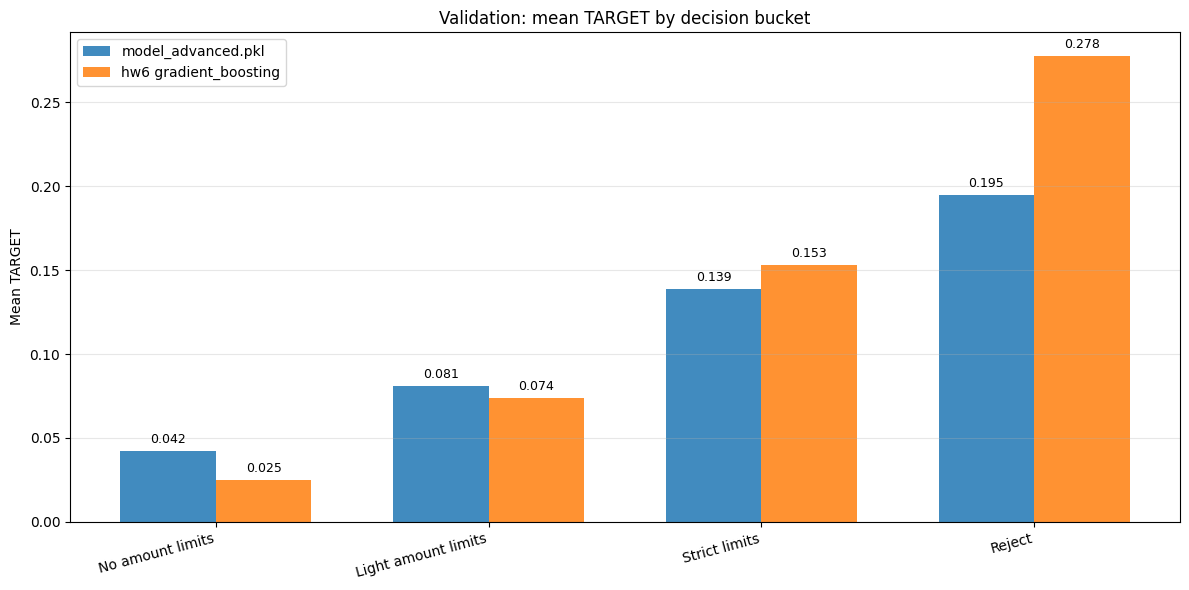

Saved: C:\Users\denis\credit_scoring\notebooks\hw7\metrics\02_decision_categories_target_shift_hw6_vs_advanced.png


In [17]:
validation_cmp = assign_categories(validation_cmp, "DECILE_advanced", "CLIENT_CATEGORY_advanced")
validation_cmp = assign_categories(validation_cmp, "DECILE_hw6", "CLIENT_CATEGORY_hw6")

category_summary_advanced = validation_cmp.groupby(
    "CLIENT_CATEGORY_advanced",
    observed=True,
).agg(
    count=pd.NamedAgg(column="SK_ID_CURR", aggfunc="count"),
    target=pd.NamedAgg(column=TARGET, aggfunc="mean"),
)

category_summary_hw6 = validation_cmp.groupby(
    "CLIENT_CATEGORY_hw6",
    observed=True,
).agg(
    count=pd.NamedAgg(column="SK_ID_CURR", aggfunc="count"),
    target=pd.NamedAgg(column=TARGET, aggfunc="mean"),
)

category_compare = pd.DataFrame(
    {
        "advanced_target": category_summary_advanced["target"],
        "hw6_target": category_summary_hw6["target"],
        "advanced_count": category_summary_advanced["count"],
        "hw6_count": category_summary_hw6["count"],
    }
)

display(category_compare)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(category_compare.index))
width = 0.35

ax.bar(
    x - width / 2,
    category_compare["advanced_target"],
    width=width,
    label=MODEL_NAME_BASE,
    alpha=0.85,
)
ax.bar(
    x + width / 2,
    category_compare["hw6_target"],
    width=width,
    label=MODEL_NAME_CANDIDATE,
    alpha=0.85,
)

ax.set_xticks(x)
ax.set_xticklabels(category_compare.index, rotation=15, ha="right")
ax.set_ylabel("Mean TARGET")
ax.set_title("Validation: mean TARGET by decision bucket")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

for i, (adv_val, hw6_val) in enumerate(
    zip(category_compare["advanced_target"], category_compare["hw6_target"])
):
    ax.text(i - width / 2, adv_val + 0.003, f"{adv_val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + width / 2, hw6_val + 0.003, f"{hw6_val:.3f}", ha="center", va="bottom", fontsize=9)

category_path = metrics_dir / "02_decision_categories_target_shift_hw6_vs_advanced.png"
fig.tight_layout()
fig.savefig(category_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", category_path.resolve())

 В сегменте No amount limits средний TARGET снизился с 0.042 до 0.025, а в Light amount limits с 0.081 до 0.074. Это означает, что одобряемая часть потока стала качественнее. Одновременно в более жестких сегментах риск вырос: Strict limits увеличился с 0.139 до 0.153, а Reject с 0.195 до 0.278. После замены модели принятия решений становится более чистой с точки зрения риска. 

## 9. Визуализация 3. Стабильность децилей на тестовом потоке



In [18]:
test_cmp = test_cmp.copy()
test_cmp["PROBA_advanced"] = model_advanced_cmp.predict_proba(
    test_cmp[NUMERICAL_FEATURES + CAT_FEATURES + EXT_SOURCE_FEATURES]
)[:, 1]
test_cmp["PROBA_hw6"] = model_hw6_cmp.predict_proba(
    test_cmp[HW6_ALL_FEATURES]
)[:, 1]

test_cmp = assign_test_deciles_from_validation(
    test_df=test_cmp,
    validation_df=validation_cmp,
    proba_col="PROBA_advanced",
    quantile_col="QUANTILE_advanced",
    new_col="DECILE_advanced",
)

test_cmp = assign_test_deciles_from_validation(
    test_df=test_cmp,
    validation_df=validation_cmp,
    proba_col="PROBA_hw6",
    quantile_col="QUANTILE_hw6",
    new_col="DECILE_hw6",
)

time_dist_advanced = build_time_distribution(test_cmp, "DECILE_advanced", res="3d")
time_dist_hw6 = build_time_distribution(test_cmp, "DECILE_hw6", res="3d")

display(time_dist_advanced.head())
display(time_dist_hw6.head())

DECILE_advanced,9,8,7,6,5,4,3,2,1,0
DATE_OF_APPLICATION,,,,,,,,,,
2023-01-01,0.093976,0.074699,0.118072,0.079518,0.093976,0.113253,0.098795,0.122892,0.103614,0.101205
2023-01-04,0.092807,0.113689,0.074246,0.088167,0.092807,0.120650,0.071926,0.116009,0.097448,0.132251
2023-01-07,0.103275,0.088161,0.093199,0.078086,0.065491,0.110831,0.093199,0.146096,0.133501,0.088161
2023-01-10,0.078283,0.075758,0.088384,0.090909,0.090909,0.123737,0.090909,0.106061,0.103535,0.151515
2023-01-13,0.096927,0.104019,0.070922,0.089835,0.101655,0.096927,0.094563,0.096927,0.108747,0.139480


DECILE_hw6,9,8,7,6,5,4,3,2,1,0
DATE_OF_APPLICATION,,,,,,,,,,
2023-01-01,0.089157,0.127711,0.096386,0.091566,0.089157,0.103614,0.081928,0.106024,0.110843,0.103614
2023-01-04,0.099768,0.088167,0.097448,0.095128,0.125290,0.099768,0.097448,0.095128,0.099768,0.102088
2023-01-07,0.090680,0.110831,0.118388,0.103275,0.128463,0.080605,0.083123,0.085642,0.108312,0.090680
2023-01-10,0.095960,0.088384,0.093434,0.123737,0.093434,0.106061,0.083333,0.098485,0.108586,0.108586
2023-01-13,0.082742,0.096927,0.134752,0.104019,0.089835,0.104019,0.082742,0.082742,0.111111,0.111111


Табличный срез по первым датам тестового периода показывает, что доли децилей у обеих моделей находятся в разумном диапазоне и в целом близки к ожидаемым значениям порядка 10% на дециль. Мы не видим ни схлопывания отдельных сегментов, ни аномального переполнения какого-то одного дециля уже в начале тестового периода. 

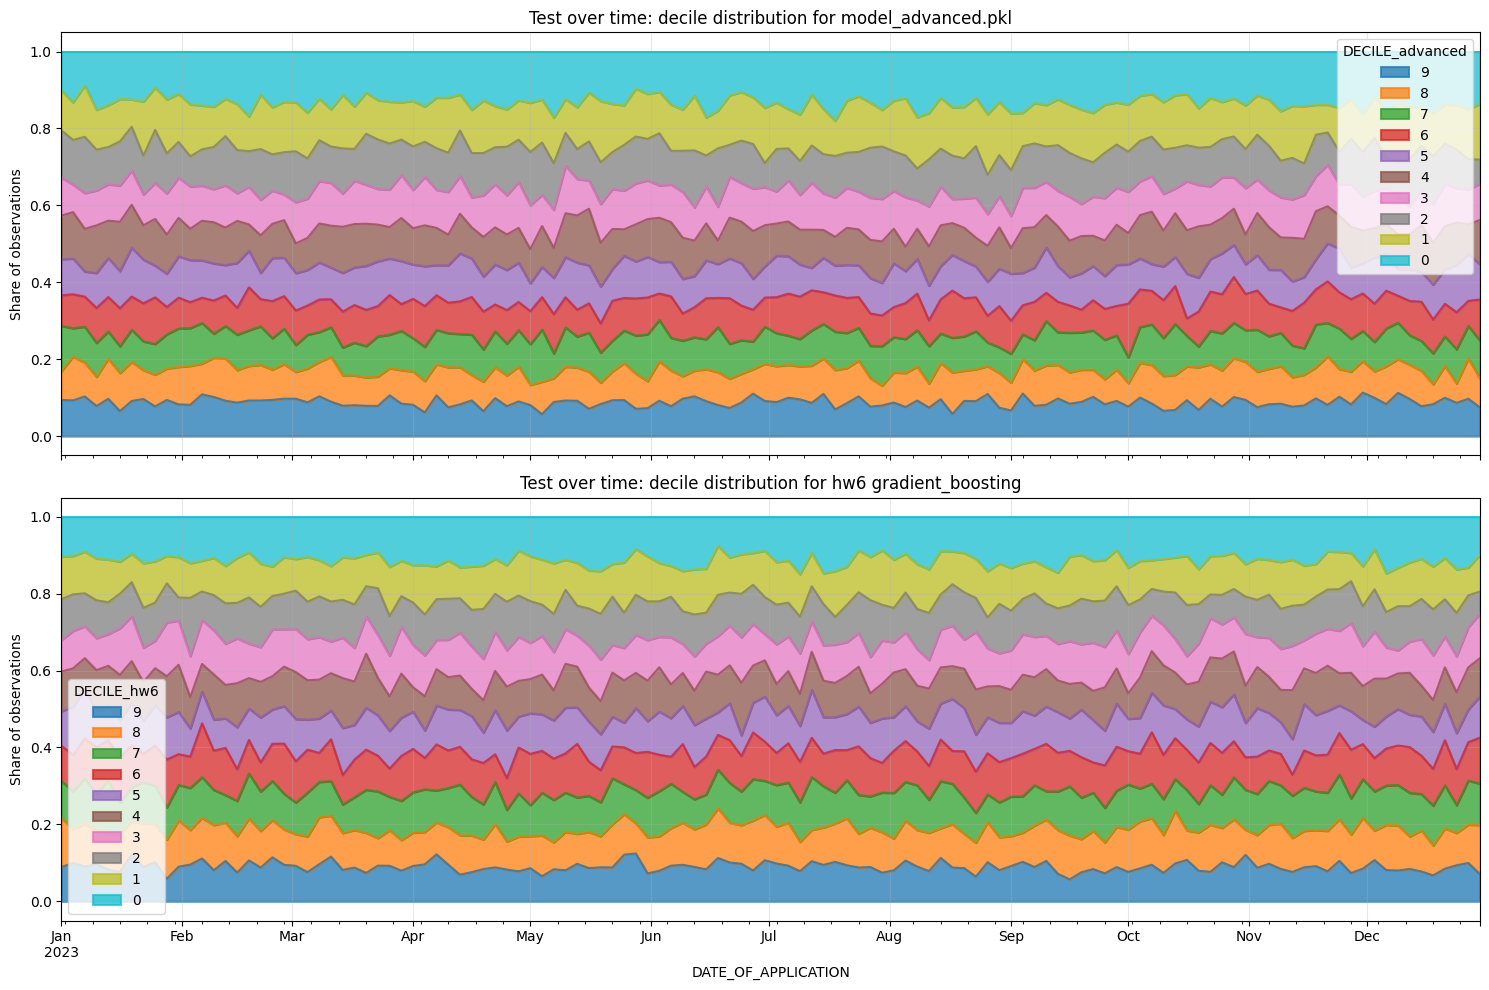

Saved: C:\Users\denis\credit_scoring\notebooks\hw7\metrics\03_test_deciles_drift_over_time_hw6_vs_advanced.png


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True, sharey=True)

time_dist_advanced.plot.area(
    ax=axes[0],
    alpha=0.75,
    lw=1.5,
)
axes[0].set_title(f"Test over time: decile distribution for {MODEL_NAME_BASE}")
axes[0].set_ylabel("Share of observations")
axes[0].grid(True, alpha=0.3)

time_dist_hw6.plot.area(
    ax=axes[1],
    alpha=0.75,
    lw=1.5,
)
axes[1].set_title(f"Test over time: decile distribution for {MODEL_NAME_CANDIDATE}")
axes[1].set_ylabel("Share of observations")
axes[1].set_xlabel("DATE_OF_APPLICATION")
axes[1].grid(True, alpha=0.3)

drift_path = metrics_dir / "03_test_deciles_drift_over_time_hw6_vs_advanced.png"
fig.tight_layout()
fig.savefig(drift_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", drift_path.resolve())

На полном временном графике выраженного дата-дрифта не наблюдается ни для baseline, ни для hw6 gradient_boosting. Доли децилей колеблются вокруг стабильных уровней, без резких режимных сдвигов, без систематического нарастания доли плохих децилей и без явного переворота структуры потока в отдельные периоды. У hw6 gradient_boosting локальные флуктуации присутствуют, как и у baseline, но визуально это скорее нормальный операционный шум, чем признак деградации модели. Получается, по графику распределения децилей во времени модель выглядит устойчивой, а сильных признаков дата дрифта нет. 

## 10. Краткое заключение

In [20]:
display(summary_metrics)

roc_delta = roc_hw6 - roc_advanced
approve_delta = (
    category_compare.loc["No amount limits", "hw6_target"]
    - category_compare.loc["No amount limits", "advanced_target"]
)
reject_delta = (
    category_compare.loc["Reject", "hw6_target"]
    - category_compare.loc["Reject", "advanced_target"]
)

if roc_delta > 0:
    ranking_comment = f"Кандидат улучшил ROC-AUC на{roc_delta:.3f}."
else:
    ranking_comment = f"Кандидат уступает базовой модели на {abs(roc_delta):.3f} пунктов ROC-AUC"

if approve_delta < 0:
    approve_comment = (
        "Сегмент 'Без лимитов' стал безопаснее: "
        f"TARGET change = {approve_delta:.3f}."
    )
else:
    approve_comment = (
        "Сегмент 'Без лимитов' стал рискованнее:"
        f"TARGET change = {approve_delta:.3f}."
    )

if reject_delta > 0:
    reject_comment = (
        "Сегмент 'Отказ' стал более сконцентрированным на рискованных клиентах: "
        f"TARGET change = +{reject_delta:.3f}."
    )
else:
    reject_comment = (
        "Сегмент 'Отказ' стал менеее сконцентрированным на рискованных клиентах:"
        f"TARGET change = {reject_delta:.3f}."
    )

summary_md = f"""
### Вывод

- **Baseline:** `{MODEL_NAME_BASE}`, ROC-AUC = **{roc_advanced:.3f}**
- **HW6:** `{MODEL_NAME_CANDIDATE}`, ROC-AUC = **{roc_hw6:.3f}**
- {ranking_comment}
- {approve_comment}
- {reject_comment}
- Сохраним в `{metrics_dir.resolve()}`.
"""

display(Markdown(summary_md))

print("Сохраним пнг")
for p in sorted(metrics_dir.glob("*.png")):
    print(" -", p.name)

,model,roc_auc_validation
0,model_advanced.pkl,0.673245
1,hw6 gradient_boosting,0.756822



### Вывод

- **Baseline:** `model_advanced.pkl`, ROC-AUC = **0.673**
- **HW6:** `hw6 gradient_boosting`, ROC-AUC = **0.757**
- Кандидат улучшил ROC-AUC на0.084.
- Сегмент 'Без лимитов' стал безопаснее: TARGET change = -0.017.
- Сегмент 'Отказ' стал более сконцентрированным на рискованных клиентах: TARGET change = +0.083.
- Сохраним в `C:\Users\denis\credit_scoring\notebooks\hw7\metrics`.


Сохраним пнг
 - 01_validation_sort_curve_hw6_vs_advanced.png
 - 02_decision_categories_target_shift_hw6_vs_advanced.png
 - 03_test_deciles_drift_over_time_hw6_vs_advanced.png
 - 04_validation_decile_transition_matrix_hw6_vs_advanced.png


Все графики говорят в пользу hw6 gradient_boosting. Новая модель лучше ранжирует клиентов по риску, чище раскладывает поток по решающим сегментам и при этом не показывает признаков выраженной временной нестабильности на тесте. Практически это означает, что при переходе на hw6 gradient_boosting можно ожидать более качественное отделение низкорисковых клиентов от высокорисковых и более управляемую кредитную политику.